# MBAR 

Updated: 12/21/2024 

By: van

In [1]:
!printf "This notebook is found in...\n$(echo $(realpath .))"

This notebook is found in...
/scratch/van/ippoi/qmmm/wildtype/mbar

In [2]:
import os
import sys
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
#from matplotlib.ticker import AutoMinorLocator, LogLocator, NullFormatter
# plt.style.use('/home/van/Scripts/bin/v.mplstyle')
import seaborn as sb
from glob import glob
from sklearn.utils import resample

import pymbar
from pymbar.mbar_pmf import mbar_pmf

In [3]:
os.makedirs('img', exist_ok=True)
os.makedirs('freefiles', exist_ok=True)
os.makedirs('entropies', exist_ok=True)

In [5]:
# CV file from {step}.{rep}_equilibration.cv
step="step6"
rep="0?"

n_windows = 42
val_min = -1.90 # restraint at window 00
val_max = 2.20  # restraint at window 41
fc = 300.0      # forces constant for restraint - AMBERVALUE*2 - Richard had AMBERVALUE=150.0
nbins = n_windows - 1


In [6]:

val0_k = np.linspace(val_min, val_max, n_windows)
K_k = np.ones(n_windows) * fc


In [7]:

val_kn = []
for i in range(n_windows):
    fnames = sorted(glob(f'../{i:02d}/{step}.{rep}_equilibration.cv'))
    arrays = [np.loadtxt(f, usecols=1)[::] for f in fnames[:]]
    val_kn.append(np.concatenate(arrays))


In [8]:

for i in range(n_windows):
    print("Window %02d:" % i, pymbar.timeseries.subsampleCorrelatedData(val_kn[i], conservative=True))
    

Window 00: range(0, 2400, 2)
Window 01: range(0, 2400, 2)
Window 02: range(0, 1995, 2)
Window 03: range(0, 2400, 2)
Window 04: range(0, 2027, 2)
Window 05: range(0, 1462, 2)
Window 06: range(0, 2400, 2)
Window 07: range(0, 1452, 2)
Window 08: range(0, 1455, 2)
Window 09: range(0, 2400)
Window 10: range(0, 2400)
Window 11: range(0, 1388)
Window 12: range(0, 2400, 2)
Window 13: range(0, 2400, 2)
Window 14: range(0, 2400, 2)
Window 15: range(0, 2400, 2)
Window 16: range(0, 2400, 2)
Window 17: range(0, 2400, 2)
Window 18: range(0, 2400, 2)
Window 19: range(0, 2400, 2)
Window 20: range(0, 1654, 4)
Window 21: range(0, 2400, 2)
Window 22: range(0, 2400, 2)
Window 23: range(0, 2400, 3)
Window 24: range(0, 1879, 3)
Window 25: range(0, 1875, 3)
Window 26: range(0, 2400, 3)
Window 27: range(0, 1954, 2)
Window 28: range(0, 1959, 2)
Window 29: range(0, 1955, 2)
Window 30: range(0, 1949, 2)
Window 31: range(0, 2400, 2)
Window 32: range(0, 2400, 3)
Window 33: range(0, 2108, 2)
Window 34: range(0, 240

In [9]:
# mbar = mbar_B(val_kn, val0_k, K_k, 300.0, u_kn=np.array(ene_pm3))
mbar = mbar_pmf(val_kn, val0_k, K_k, fc)

K (total states) = 42, total samples = 91327
N_k = 
[2400 2400 1995 2400 2027 1462 2400 1452 1455 2400 2400 1388 2400 2400
 2400 2400 2400 2400 2400 2400 1654 2400 2400 2400 1879 1875 2400 1954
 1959 1955 1949 2400 2400 2108 2400 1832 2400 2400 2400 2400 2400 1983]
There are 42 states with samples.
Initial dimensionless free energies with method BAR
f_k = 
[ 0.00000000e+00 -2.23514772e-01 -1.22122179e-01 -1.83483286e-02
  2.00199188e-01  7.30799922e-01  1.43434832e+00  2.10493503e+00
  2.83776316e+00  3.89621140e+00  5.17237068e+00  6.71117635e+00
  8.30984215e+00  1.00762937e+01  1.19644357e+01  1.36678988e+01
  1.53576490e+01  1.71425276e+01  1.90895405e+01  2.11142630e+01
  2.27990281e+01  2.33832929e+01  2.36768368e+01  2.37806787e+01
  2.36227481e+01  2.33561174e+01  2.27861941e+01  2.21593056e+01
  2.14553857e+01  2.05755866e+01  1.96724457e+01  1.90323743e+01
  1.85609252e+01  1.82974902e+01  1.85528016e+01  1.90258138e+01
  1.96062239e+01  2.02658108e+01  2.10044733e+01  2.1632

In [10]:

bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins)
bin_centers, f_i, df_i, reweighting_entropy = mbar.get_pmf(val_min, val_max, nbins, uncertainties='from-specified', pmf_reference=f_i[:20].argmin())
np.savetxt(f"freefiles/freefile_mbar_{step}.{rep}", np.column_stack((bin_centers, f_i, df_i)))

# Histogram + Preliminary PMF 

## _Not for publication_

In [11]:
initial = np.loadtxt(f"freefiles/freefile_mbar_{step}.{rep}")

xdata=initial[:,0]
ydata=initial[:,1] - initial[:10,1].min()
edata=initial[:,2]

dgd = round(initial[:,1].max() - initial[:10,1].min(),1) # Delta G daggerV
err = round(initial[initial[:,1].argmax()][2], 1) # mbar error

c=sb.color_palette('deep', n_windows)
_xfrac=0.05
_yfrac=0.9

opa=0.4

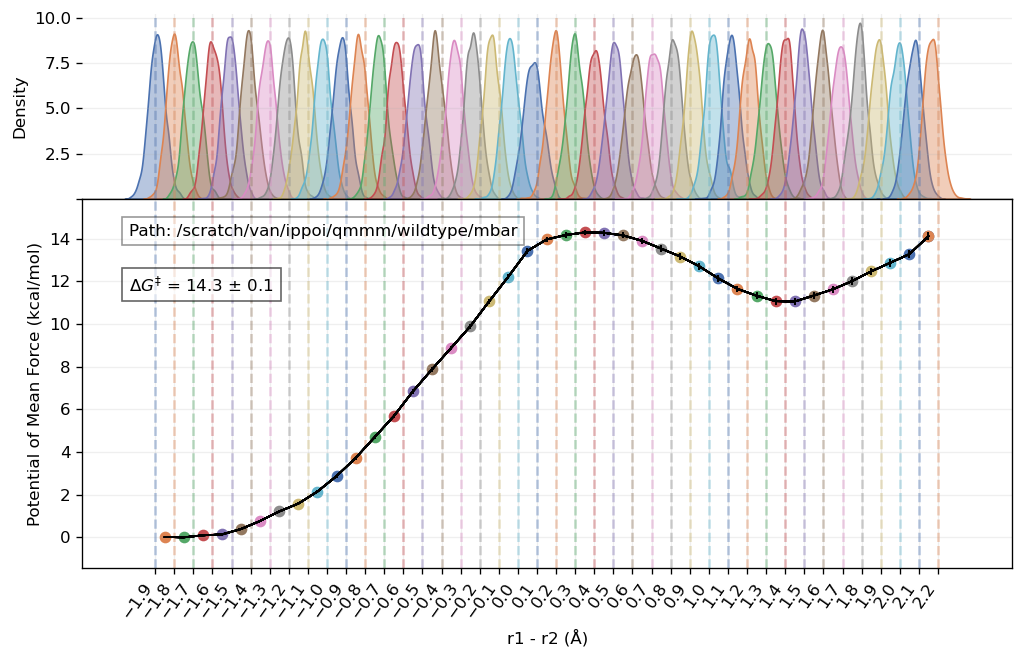

In [12]:
# fig = plt.figure(sharex=True, figsize=(7.5,5), dpi=150)
fig = plt.figure(figsize=(10,6), dpi=120)

axs = fig.subplot_mosaic(
    """
    A
    B
    """,height_ratios=[1,2],sharex=True)

for i in range(n_windows):
    sb.kdeplot(val_kn[i], fill=True, alpha=opa, ax=axs['A'], color=c[i])
    axs['A'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
    axs['A'].yaxis.get_major_ticks()[0].label1.set_visible(False)
    axs['A'].grid(linestyle='-', alpha=opa-0.2)

    
    axs['B'].errorbar(xdata, ydata, yerr=edata, linewidth=1, c='black', alpha=opa+0.1)
    axs['B'].scatter(xdata[i-1], ydata[i-1], color=c[i])
    axs['B'].axvline(x=val0_k[i], linestyle='--', alpha=opa, color=c[i])
    axs['B'].grid(linestyle='-', alpha=opa-0.2)
    

axs['B'].annotate(f"Path: {os.getcwd()}", 
                    xy=(_xfrac, _yfrac), xycoords='axes fraction', bbox=dict(fc="w", alpha=opa))
axs['B'].annotate(f"$\Delta G^\ddag$ = {dgd} $\pm$ {err}", 
                    xy=(_xfrac,_yfrac-0.15), xycoords='axes fraction',bbox=dict(fc='w', alpha=opa+0.2))

axs['B'].set_xlabel("r1 - r2 (Å)")
axs['B'].set_ylabel("Potential of Mean Force (kcal/mol)")

plt.margins(x=0.00, y=0.1)
plt.xticks(ticks=val0_k, rotation=55, ha='right')

sb.despine(left=True, bottom=False, right=True, ax=axs['A'])
fig.subplots_adjust(wspace=0, hspace=0)


plt.savefig(f"img/prelim-B-{step}.{rep}.png")
plt.show()

In [43]:
# Copy notebook to templates directory

!cp mbar.ipynb /home/van/Scripts/amber/mbar/mbar.ipynb